In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BatchNorm2D(nn.Module):
    def __init__(self, num_time_steps, num_features):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_time_steps * num_features)
        self.L = num_time_steps
        self.C = num_features

    def forward(self, x):
        B, L, C = x.shape
        x_flat = x.reshape(B, L * C)
        x_norm = self.bn(x_flat)
        return x_norm.reshape(B, L, C)

In [43]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))
        self.mean = None
        self.stdev = None

    def forward(self, x, mode):
        if mode == "norm":
            self.get_statistics(x)
            x = self.normalize(x)
        elif mode == "denorm":
            x = self.denormalize(x)
        return x

    def get_statistics(self, x):
        self.mean = torch.mean(x, dim=1, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps
        ).detach()

    def normalize(self, x):
        x = (x - self.mean) / self.stdev
        if self.affine:
            x = x * self.affine_weight + self.affine_bias
        return x

    def denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps)
        return x * self.stdev + self.mean

In [44]:
class MeanScaling(nn.Module):
    def __init__(self):
        super().__init__()
        # self.eps = eps
        self.mean = None

    def forward(self, x, mode, mean=None):
        if mode == "norm":
            self.mean = torch.mean(x, dim=1, keepdim=True).detach()
            self.mean = self.mean + 1.0
            return x / self.mean, self.mean
        elif mode == "denorm":
            assert mean is not None
            return x * mean

In [45]:
class TemporalProjection(nn.Module):
    def __init__(self, in_len, out_len):
        super().__init__()
        self.linear = nn.Linear(in_len, out_len)

    def forward(self, x):
        # B, L, C = x.shape
        x_t = x.transpose(1, 2)
        out_t = self.linear(x_t)
        return out_t.transpose(1, 2)

In [46]:
class TimeMixing(nn.Module):
    def __init__(
        self, seq_len, num_features, dropout=0.0, norm_type="layer", pre_norm=False
    ):
        super().__init__()
        self.pre_norm = pre_norm
        self.tp = nn.Linear(seq_len, seq_len)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)

        if norm_type == "layer":
            self.norm = nn.LayerNorm([seq_len, num_features])
        elif norm_type == "batch":
            self.norm = BatchNorm2D(seq_len, num_features)
        else:
            self.norm = nn.Identity()

    def forward(self, x):
        if self.pre_norm:
            x_norm = self.norm(x)
            x_norm_t = x_norm.transpose(1, 2)
            out_t = self.tp(x_norm_t)
            out = out_t.transpose(1, 2)
            return x + self.drop(self.act(out))
        else:
            x_t = x.transpose(1, 2)
            out_t = self.tp(x_t)
            out = out_t.transpose(1, 2)
            return self.norm(x + self.drop(self.act(out)))


In [47]:
class FeatureMixing(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        seq_len,
        hidden_size=None,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
    ):
        super().__init__()
        self.pre_norm = pre_norm
        hidden_size = hidden_size or out_features

        self.linear1 = nn.Linear(in_features, hidden_size)
        self.act = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)
        self.linear2 = nn.Linear(hidden_size, out_features)
        self.drop2 = nn.Dropout(dropout)

        if in_features != out_features:
            self.shortcut_proj = nn.Linear(in_features, out_features)
        else:
            self.shortcut_proj = nn.Identity()

        if norm_type == "layer":
            if self.pre_norm:
                self.norm = nn.LayerNorm([seq_len, in_features])
            else:
                self.norm = nn.LayerNorm([seq_len, out_features])
        elif norm_type == "batch":
            if self.pre_norm:
                self.norm = BatchNorm2D(seq_len, in_features)
            else:
                self.norm = BatchNorm2D(seq_len, out_features)
        else:
            self.norm = nn.Identity()

    def forward(self, x):
        if self.pre_norm:
            x_norm = self.norm(x)
            u = self.drop1(self.act(self.linear1(x_norm)))
            out = self.drop2(self.linear2(u))
            return self.shortcut_proj(x) + out
        else:
            u = self.drop1(self.act(self.linear1(x)))
            out = self.drop2(self.linear2(u))
            return self.norm(self.shortcut_proj(x) + out)


In [48]:
class MixerLayer(nn.Module):
    def __init__(
        self,
        seq_len,
        num_features,
        hidden_size=None,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
    ):
        super().__init__()
        self.tm = TimeMixing(seq_len, num_features, dropout, norm_type, pre_norm)
        self.fm = FeatureMixing(
            num_features,
            num_features,
            seq_len,
            hidden_size,
            dropout,
            norm_type,
            pre_norm,
        )

    def forward(self, x):
        return self.fm(self.tm(x))


In [49]:

class TSMixer(nn.Module):
    def __init__(
        self,
        seq_len,
        pred_len,
        num_features,
        num_blocks=2,
        hidden_size=None,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
        use_revin=False,
    ):
        super().__init__()
        self.use_revin = use_revin
        if self.use_revin:
            self.revin = RevIN(num_features)

        self.blocks = nn.ModuleList(
            [
                MixerLayer(
                    seq_len, num_features, hidden_size, dropout, norm_type, pre_norm
                )
                for _ in range(num_blocks)
            ]
        )
        self.tp = TemporalProjection(seq_len, pred_len)

    def forward(self, x):
        if self.use_revin:
            x = self.revin(x, "norm")

        for block in self.blocks:
            x = block(x)

        out = self.tp(x)

        if self.use_revin:
            out = self.revin(out, "denorm")
        return out

In [50]:
class StaticEmbeddingBlock(nn.Module):
    def __init__(self, cat_cardinalities, cat_emb_dims, continuous_dim, out_dim):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [
                nn.Embedding(num_embeddings=card, embedding_dim=dim)
                for card, dim in zip(cat_cardinalities, cat_emb_dims)
            ]
        )
        total_dim = sum(cat_emb_dims) + continuous_dim
        self.proj = nn.Linear(total_dim, out_dim)

    def forward(self, s_cat, s_cont):
        embedded = []
        for i, emb_layer in enumerate(self.embeddings):
            col_ids = s_cat[:, i].long()
            embedded.append(emb_layer(col_ids))

        s_all = torch.cat(embedded + [s_cont], dim=-1)
        return self.proj(s_all)

In [51]:
class ConditionalFeatureMixing(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        seq_len,
        static_dim,
        hidden_size=None,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
    ):
        super().__init__()
        self.fr = nn.Linear(static_dim, out_features)
        self.fm = FeatureMixing(
            in_features + out_features,
            out_features,
            seq_len,
            hidden_size,
            dropout,
            norm_type,
            pre_norm,
        )

    def forward(self, x, v_static):
        B, T, _ = x.shape
        v_proj = self.fr(v_static)
        v_expanded = v_proj.unsqueeze(1).expand(-1, T, -1)
        x_concat = torch.cat([x, v_expanded], dim=-1)
        return self.fm(x_concat)


In [52]:
class ConditionalMixerLayer(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        seq_len,
        static_dim,
        hidden_size=None,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
    ):
        super().__init__()
        self.tm = TimeMixing(seq_len, in_features, dropout, norm_type, pre_norm)
        self.cfm = ConditionalFeatureMixing(
            in_features,
            out_features,
            seq_len,
            static_dim,
            hidden_size,
            dropout,
            norm_type,
            pre_norm,
        )

    def forward(self, x, v_static):
        return self.cfm(self.tm(x), v_static)

In [53]:
class TSMixerExt(nn.Module):
    def __init__(
        self,
        seq_len,
        pred_len,
        num_features,
        hist_exog_dim,
        futr_exog_dim,
        static_cont_dim,
        cat_cardinalities=None,
        cat_emb_dims=None,
        num_blocks=2,
        hidden_size=64,
        dropout=0.0,
        norm_type="layer",
        pre_norm=False,
        probabilistic=False,
        use_mean_scaling=False,
    ):
        super().__init__()
        self.probabilistic = probabilistic
        self.use_mean_scaling = use_mean_scaling

        if self.use_mean_scaling:
            self.mean_scaler = MeanScaling()

        self.has_embeddings = cat_cardinalities is not None and cat_emb_dims is not None
        if self.has_embeddings:
            self.static_embedder = StaticEmbeddingBlock(
                cat_cardinalities=cat_cardinalities,
                cat_emb_dims=cat_emb_dims,
                continuous_dim=static_cont_dim,
                out_dim=hidden_size,
            )
            static_dim_for_mix = hidden_size
        else:
            self.static_embedder = nn.Linear(static_cont_dim, hidden_size)
            static_dim_for_mix = hidden_size

        self.tp_past = TemporalProjection(seq_len, pred_len)
        self.cfm_past = ConditionalFeatureMixing(
            in_features=num_features + hist_exog_dim,
            out_features=hidden_size,
            seq_len=pred_len,
            static_dim=static_dim_for_mix,
            hidden_size=hidden_size,
            dropout=dropout,
            norm_type=norm_type,
            pre_norm=pre_norm,
        )

        self.cfm_futr = ConditionalFeatureMixing(
            in_features=futr_exog_dim,
            out_features=hidden_size,
            seq_len=pred_len,
            static_dim=static_dim_for_mix,
            hidden_size=hidden_size,
            dropout=dropout,
            norm_type=norm_type,
            pre_norm=pre_norm,
        )

        self.block1 = ConditionalMixerLayer(
            in_features=2 * hidden_size,
            out_features=hidden_size,
            seq_len=pred_len,
            static_dim=static_dim_for_mix,
            hidden_size=hidden_size,
            dropout=dropout,
            norm_type=norm_type,
            pre_norm=pre_norm,
        )

        self.blocks = nn.ModuleList(
            [
                ConditionalMixerLayer(
                    in_features=hidden_size,
                    out_features=hidden_size,
                    seq_len=pred_len,
                    static_dim=static_dim_for_mix,
                    hidden_size=hidden_size,
                    dropout=dropout,
                    norm_type=norm_type,
                    pre_norm=pre_norm,
                )
                for _ in range(num_blocks - 1)
            ]
        )

        if self.probabilistic:
            self.mu_head = nn.Linear(hidden_size, num_features)
            self.alpha_head = nn.Linear(hidden_size, num_features)
        else:
            self.fc_head = nn.Linear(hidden_size, num_features)

    def forward(self, x, x_hist_exog, z_futr, s_cat=None, s_cont=None):
        mean_scale = None
        if self.use_mean_scaling:
            x, mean_scale = self.mean_scaler(x, "norm")

        if self.has_embeddings:
            assert s_cat is not None and s_cont is not None, (
                "Metadata category indices required"
            )
            v_static = self.static_embedder(s_cat, s_cont)
        else:
            assert s_cont is not None, "Continuous static features required"
            v_static = self.static_embedder(s_cont)

        past_concat = torch.cat([x, x_hist_exog], dim=-1)
        past_proj = self.tp_past(past_concat)
        x_aligned = self.cfm_past(past_proj, v_static)

        z_aligned = self.cfm_futr(z_futr, v_static)

        h = torch.cat([x_aligned, z_aligned], dim=-1)
        h = self.block1(h, v_static)

        for block in self.blocks:
            h = block(h, v_static)

        if self.probabilistic:
            mu = F.softplus(self.mu_head(h)) + 1e-4
            alpha = F.softplus(self.alpha_head(h)) + 1e-4
            if self.use_mean_scaling:
                mu = self.mean_scaler(mu, "denorm", mean_scale)
            return mu, alpha
        else:
            out = self.fc_head(h)
            if self.use_mean_scaling:
                out = self.mean_scaler(out, "denorm", mean_scale)
            return out




In [54]:
class NegativeBinomialLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, mu, alpha, y):
        mu = torch.clamp(mu, min=self.eps)
        alpha = torch.clamp(alpha, min=self.eps)
        total_count = 1.0 / alpha
        probs = 1.0 / (1.0 + alpha * mu)
        probs = torch.clamp(probs, min=self.eps, max=1.0 - self.eps)
        dist = torch.distributions.NegativeBinomial(
            total_count=total_count, probs=probs
        )
        return -dist.log_prob(y).mean()



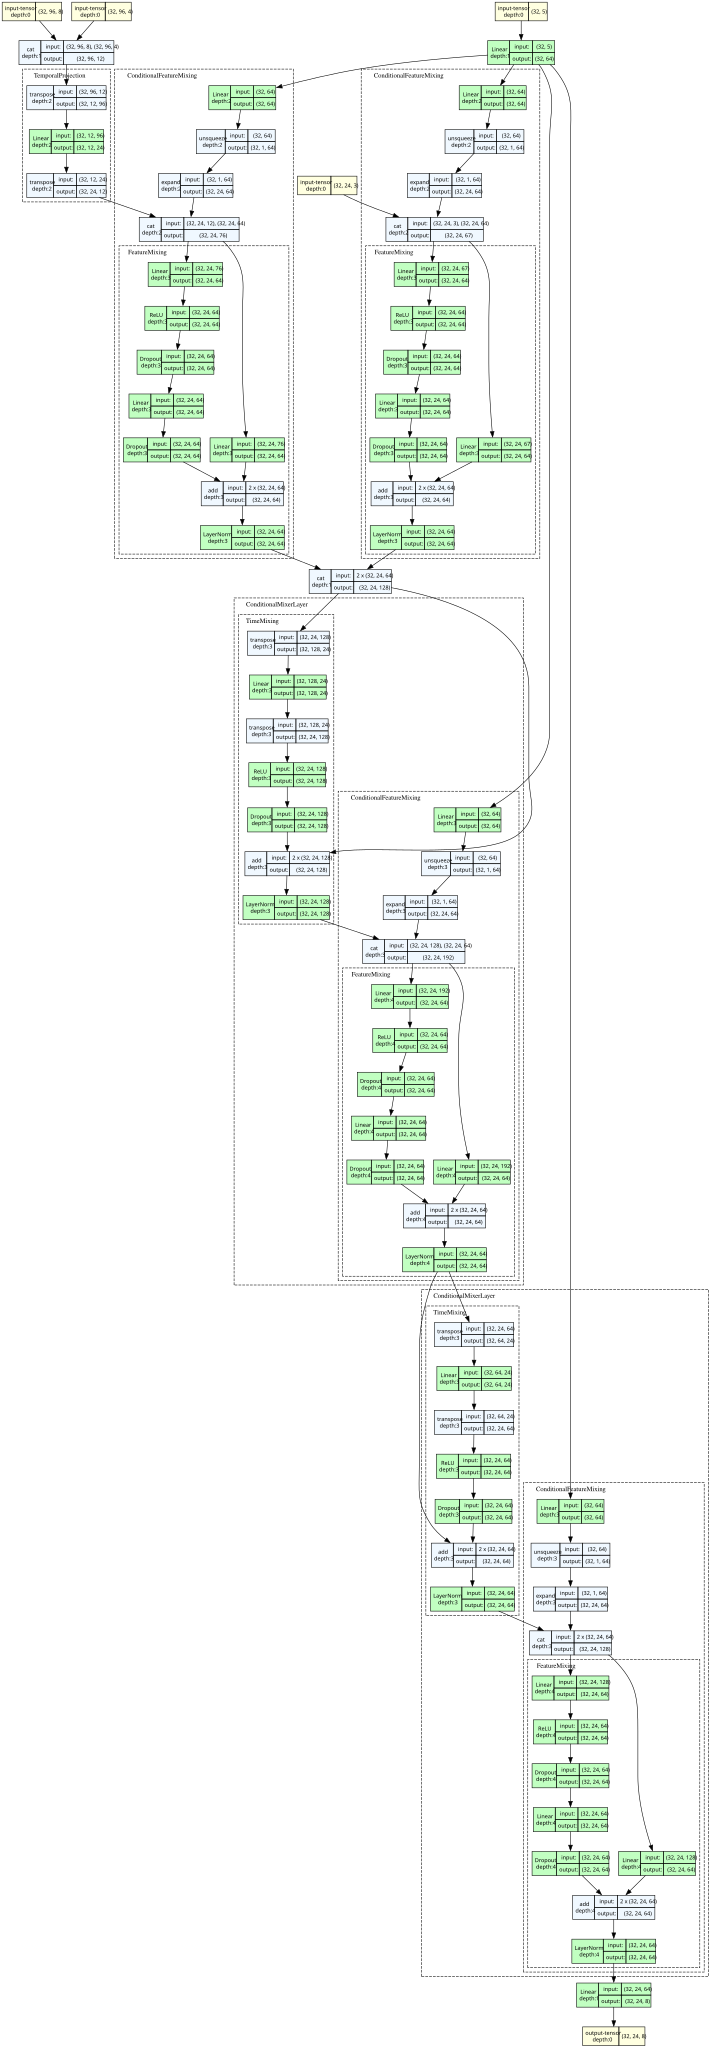

In [55]:
import torch
from torchview import draw_graph
# from tsmixer_m5.modeling import TSMixerExt
model = TSMixerExt(
    seq_len=96,
    pred_len=24,
    num_features=8,
    hist_exog_dim=4,
    futr_exog_dim=3,
    static_cont_dim=5,
    hidden_size=64,
)

B = 32

x = torch.randn(B, 96, 8)
x_hist_exog = torch.randn(B, 96, 4)
z_futr = torch.randn(B, 24, 3)
s_cont = torch.randn(B, 5)

graph = draw_graph(
    model,
    input_data=(x, x_hist_exog, z_futr, None, s_cont),
    expand_nested=True,
    depth=6,
)

graph.visual_graph

In [2]:
"""
Build a native W&B Report for the tsmixer-m5 project.

Install:
    pip install wandb-workspaces --break-system-packages

Auth (once):
    wandb login

Run:
    python build_report.py
"""

import wandb_workspaces.reports.v2 as wr

ENTITY = "olandechris-"
PROJECT = "tsmixer-m5"

report = wr.Report(
    entity=ENTITY,
    project=PROJECT,
    title="TSMixer-M5 — Sub-Hierarchical Oblique Projections",
    description=(
        "Optuna sweep + final multi-seed evaluation for the M5 California "
        "forecasting project."
    ),
)

blocks = []

# ---------------------------------------------------------------- overview
blocks += [
    wr.H1("Overview"),
    wr.P(
        "Two experiment groups make up this project: a 62-trial Optuna "
        "hyperparameter search (optuna_sweep) and 5 confirmatory multi-seed "
        "training runs (final_training). 45 of 62 sweep trials (72.6%) were "
        "pruned; 15 ran to completion."
    ),
]

# ---------------------------------------------------------- sweep: pruning
sweep_runset = wr.Runset(
    entity=ENTITY,
    project=PROJECT,
    name="Optuna sweep",
    filters="Group == 'optuna_sweep'",
)

blocks += [
    wr.H1("Optuna sweep: pruning behaviour"),
    wr.P(
        "82% of pruned trials (37/45) were cut at epoch 1 — worth widening "
        "n_startup_trials on the pruner next sweep, since early-epoch loss "
        "has historically been misleading on this pipeline (mean-scaling bug)."
    ),
    wr.PanelGrid(
        runsets=[sweep_runset],
        panels=[
            wr.BarPlot(
                title="Pruned trials by epoch",
                metrics=["epoch"],
            ),
            wr.ScatterPlot(
                title="Learning rate vs final WRMSSE (completed trials)",
                x="lr",
                y="final_wrmsse",
            ),
            wr.ScatterPlot(
                title="num_batches_per_epoch vs final WRMSSE",
                x="num_batches_per_epoch",
                y="final_wrmsse",
            ),
            wr.BarPlot(
                title="Final WRMSSE by trial (completed only)",
                metrics=["final_wrmsse"],
            ),
        ],
    ),
]

# ------------------------------------------------------- final training
final_runset = wr.Runset(
    entity=ENTITY,
    project=PROJECT,
    name="Final training",
    filters="Group == 'final_training'",
)

blocks += [
    wr.H1("Final training: multi-seed evaluation"),
    wr.P(
        "Config A (hidden=128, blocks=2, batch=512, dropout=0.2) ran 3 clean "
        "seeds: test WRMSSE 0.653 +/- 0.021. Config B (hidden=256, blocks=4, "
        "batch=1024, dropout=0.0) ran 2 seeds, one of which crashed at epoch "
        "29; its one clean result was 0.684 test WRMSSE. "
        "Recommendation: report Config A as the final model — it beat Config B "
        "under multi-seed confirmation despite Config B producing the single "
        "best sweep trial (trial_014, WRMSSE 0.575)."
    ),
    wr.PanelGrid(
        runsets=[final_runset],
        panels=[
            wr.BarPlot(
                title="Test WRMSSE by seed",
                metrics=["test_wrmsse"],
                groupby="hidden_size",
            ),
            wr.BarPlot(
                title="Val WRMSSE by seed",
                metrics=["val_wrmsse"],
                groupby="hidden_size",
            ),
            wr.ScalarChart(
                title="Mean test WRMSSE",
                metric="test_wrmsse",
                groupby_aggfunc="mean",
            ),
            wr.LinePlot(
                title="Val NLL over training",
                x="epoch",
                y=["val_nll"],
                groupby="seed",
            ),
        ],
    ),
]

# ----------------------------------------------------------------- findings
blocks += [
    wr.H1("Key findings"),
    wr.UnorderedList(
        items=[
            "Config A generalizes more consistently than Config B despite "
            "losing on best single sweep trial.",
            "Consistent val -> test generalization gap of ~0.066 WRMSSE "
            "across all 3 Config A seeds — check for a train/eval split "
            "effect (holidays/promotions in test window).",
            "Config B's crash (seed 43) correlates with a worse best_val at "
            "a similar epoch vs its seed-42 sibling — consistent with known "
            "CUDA OOM / dense-projection-matrix instability at hidden=256, "
            "batch=1024.",
            "82% of pruned trials died at epoch 1 — pruner is deciding on "
            "very little signal; consider raising n_startup_trials.",
            "num_batches_per_epoch's strong naive correlation (r ~ -0.88) "
            "with final_wrmsse is a 3-vs-12 trial confound, not a genuine "
            "hyperparameter effect — don't cite it as a finding.",
        ]
    ),
]

report.blocks = blocks
report.save()

print(f"Report saved: {report.url}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/olande/.netrc.
wandb: Saved report to: https://wandb.ai/olandechris-/tsmixer-m5/reports/TSMixer-M5-—-Sub-Hierarchical-Oblique-Projections--VmlldzoxNzY5MjI1MA==


Report saved: https://wandb.ai/olandechris-/tsmixer-m5/reports/TSMixer-M5-—-Sub-Hierarchical-Oblique-Projections--VmlldzoxNzY5MjI1MA==
